# 05. Сравнение классических ML-моделей

**Цель:** сравнить 5 классических моделей на одном фиксированной train/test split:
1. **RandomForest** (baseline, перенесён из 04 — артефакт перезагружается).
2. **LightGBM** — gradient boosting, CPU.
3. **XGBoost** — gradient boosting, GPU (`device='cuda'`).
4. **DecisionTree** — одно дерево как «нижний предел» tree-based семейства.
5. **GaussianNaiveBayes** — линейный/вероятностный baseline для контраста
   с tree-based (по итогам 02: NB чувствителен к Пирсону, проигрывает
   на нелинейных связях, которые мы видели в PIAT/PS).


**Выходы:**
- `model_lightgbm.joblib`, `model_xgboost.joblib`,
  `model_decision_tree.joblib`, `model_naive_bayes.joblib`.
- `classic_ml_comparison.csv` — сравнительная таблица.
- `fig_05_roc_all.png`, `fig_05_pr_all.png`,
  `fig_05_f1_vs_time.png`.

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    roc_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

CACHE_DIR = PROJECT_ROOT / "cache"
ARTIFACTS = PROJECT_ROOT / "artifacts"
FIG_DIR   = PROJECT_ROOT / "results" / "figures"
TAB_DIR   = PROJECT_ROOT / "results" / "tables"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.metrics import compute_binary_metrics, confusion_matrix_dict

print("sklearn :", sklearn.__version__)
print("lightgbm:", lgb.__version__)
print("xgboost :", xgb.__version__)

sklearn : 1.8.0
lightgbm: 4.6.0
xgboost : 3.2.0


In [2]:
X_train = pd.read_parquet(CACHE_DIR / "X_train.parquet")
X_test  = pd.read_parquet(CACHE_DIR / "X_test.parquet")
y_train = pd.read_parquet(CACHE_DIR / "y_train.parquet")["target"].values
y_test  = pd.read_parquet(CACHE_DIR / "y_test.parquet" )["target"].values

with (ARTIFACTS / "preprocessing_config.json").open() as f:
    pp_config = json.load(f)
MODEL_FEATURES = pp_config["model_features"]

assert list(X_train.columns) == MODEL_FEATURES
assert list(X_test.columns)  == MODEL_FEATURES
assert X_train.shape[1] == 42

X_train_np = X_train.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
print(f"X_train: {X_train_np.shape}, X_test: {X_test_np.shape}")
print(f"y_train anomaly: {y_train.mean()*100:.2f}%, "
      f"y_test anomaly: {y_test.mean()*100:.2f}%")

X_train: (1477791, 42), X_test: (633340, 42)
y_train anomaly: 23.63%, y_test anomaly: 23.63%


## 1. Функция-обертка дял обучения и сбора результатов

Создание функции `train_and_evaluate`:
1) Обучение модели, замер `fit_time`
2) Выполнение `predict` + `predict_proba` на `test` с замером `predict_time`
3) Вычисление 12 метрик с помощью `compute_binary_metrics`
4) Возвращение кортежа - `(model, metrics, fit_time, predict_time)`.

In [3]:
# Обучает model, считает метрики на test. Возвращает dict с результатами
def train_and_evaluate(model, X_tr, y_tr, X_te, y_te, *,
                       proba_callable: str = "predict_proba",
                       name: str = ""):
    
    print(f"\n=== {name} ===")
    print(f"  fit on X={X_tr.shape}...")
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    print(f"  fit_time: {fit_time:.2f} sec")

    t0 = time.time()
    y_pred = model.predict(X_te)
    if proba_callable == "predict_proba":
        y_score = model.predict_proba(X_te)[:, 1]
    elif proba_callable == "decision_function":
        y_score = model.decision_function(X_te)
    else:
        y_score = None
    predict_time = time.time() - t0
    print(f"  predict_time: {predict_time:.2f} sec "
          f"({len(y_te) / predict_time:,.0f} flow/sec)")

    metrics_test = compute_binary_metrics(y_te, y_pred, y_score)

    # train metrics для overfit-check
    y_pred_tr = model.predict(X_tr)
    if proba_callable == "predict_proba":
        y_score_tr = model.predict_proba(X_tr)[:, 1]
    else:
        y_score_tr = None
    metrics_train = compute_binary_metrics(y_tr, y_pred_tr, y_score_tr)

    cm_test  = confusion_matrix_dict(y_te, y_pred)
    cm_train = confusion_matrix_dict(y_tr, y_pred_tr)

    print(f"  f1_anomaly: train={metrics_train['f1_anomaly']:.4f}, "
          f"test={metrics_test['f1_anomaly']:.4f}, "
          f"overfit gap={metrics_train['f1_anomaly'] - metrics_test['f1_anomaly']:+.4f}")
    print(f"  roc_auc test: {metrics_test['roc_auc']:.4f}")

    return {
        "model": model,
        "metrics_test": metrics_test,
        "metrics_train": metrics_train,
        "cm_test": cm_test,
        "cm_train": cm_train,
        "fit_time": fit_time,
        "predict_time_test": predict_time,
        "y_score_test": y_score,  # для общего ROC/PR графика
    }

## 2. RandomForest - загрузка артефакта

In [4]:
rf_art = joblib.load(ARTIFACTS / "model_rf_baseline.joblib")
rf_model = rf_art["model"]

t0 = time.time()
y_score_rf = rf_model.predict_proba(X_test_np)[:, 1]
rf_predict_time = time.time() - t0

# Единый формат
results = {
    "RandomForest": {
        "model": rf_model,
        "metrics_test":  rf_art["metrics_test"],
        "metrics_train": rf_art["metrics_train"],
        "cm_test":       rf_art["confusion_matrix_test"],
        "cm_train":      rf_art["confusion_matrix_train"],
        "fit_time":      rf_art["fit_time_sec"],
        "predict_time_test": rf_predict_time,
        "y_score_test":  y_score_rf,
    }
}
print(f"RF reloaded. F1_test={rf_art['metrics_test']['f1_anomaly']:.4f}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


RF reloaded. F1_test=0.9988


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished


## 3. LightGBM

Дефолтные параметры:
- `n_estimators=100, learning_rate=0.1, num_leaves=31, max_depth=-1`.
- `objective='binary', metric='binary_logloss'`.
- `n_jobs=-1, random_state=42`.
- CPU режим (не GPU)
- `verbose=-1` чтобы не засорял вывод.

In [5]:
lgb_params = {
    "objective":       "binary",
    "n_estimators":    100,
    "learning_rate":   0.1,
    "num_leaves":      31,
    "max_depth":       -1,
    "n_jobs":          -1,
    "random_state":    RANDOM_STATE,
    "verbose":         -1,
}
lgb_model = lgb.LGBMClassifier(**lgb_params)
results["LightGBM"] = train_and_evaluate(
    lgb_model, X_train_np, y_train, X_test_np, y_test,
    proba_callable="predict_proba", name="LightGBM",
)


=== LightGBM ===
  fit on X=(1477791, 42)...
  fit_time: 2.20 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  predict_time: 0.26 sec (2,432,234 flow/sec)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  f1_anomaly: train=0.9988, test=0.9986, overfit gap=+0.0002
  roc_auc test: 0.9999


## 4. XGBoost (GPU)

Использует `device='cuda'` — современный API XGBoost.

Дефолтные параметры:
- `n_estimators=100, learning_rate=0.3, max_depth=6`.
- `tree_method='hist'` (CPU + GPU).
- `eval_metric='logloss'`, `objective='binary:logistic'`.
- `random_state=42`.

In [6]:
xgb_params = {
    "objective":      "binary:logistic",
    "eval_metric":    "logloss",
    "n_estimators":   100,
    "learning_rate":  0.3,
    "max_depth":      6,
    "tree_method":    "hist",
    "device":         "cuda",
    "random_state":   RANDOM_STATE,
    "n_jobs":         -1,
    "verbosity":      0,
}
try:
    xgb_model = xgb.XGBClassifier(**xgb_params)
    results["XGBoost"] = train_and_evaluate(
        xgb_model, X_train_np, y_train, X_test_np, y_test,
        proba_callable="predict_proba", name="XGBoost (GPU)",
    )
    xgb_actual_device = "cuda"
except Exception as e:
    print(f"GPU fit failed ({e!r}); fallback на CPU")
    xgb_params["device"] = "cpu"
    xgb_model = xgb.XGBClassifier(**xgb_params)
    results["XGBoost"] = train_and_evaluate(
        xgb_model, X_train_np, y_train, X_test_np, y_test,
        proba_callable="predict_proba", name="XGBoost (CPU fallback)",
    )
    xgb_actual_device = "cpu"
print(f"XGBoost device: {xgb_actual_device}")


=== XGBoost (GPU) ===
  fit on X=(1477791, 42)...
  fit_time: 1.13 sec
  predict_time: 0.27 sec (2,316,342 flow/sec)
  f1_anomaly: train=0.9989, test=0.9988, overfit gap=+0.0001
  roc_auc test: 0.9999
XGBoost device: cuda


## 5. DecisionTree

Одиночное дерево.
- `criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1`.
- Без bootstrap (это не RF).
- `random_state=42`.

In [7]:
dt_params = {
    "criterion":       "gini",
    "max_depth":       None,
    "min_samples_split": 2,
    "min_samples_leaf":  1,
    "random_state":    RANDOM_STATE,
}
dt_model = DecisionTreeClassifier(**dt_params)
results["DecisionTree"] = train_and_evaluate(
    dt_model, X_train_np, y_train, X_test_np, y_test,
    proba_callable="predict_proba", name="DecisionTree",
)


=== DecisionTree ===
  fit on X=(1477791, 42)...
  fit_time: 19.08 sec
  predict_time: 0.05 sec (13,392,051 flow/sec)
  f1_anomaly: train=0.9989, test=0.9986, overfit gap=+0.0003
  roc_auc test: 0.9998


## 6. GaussianNB

Линейно-параметрический классификатор, моделирует P(X|y) как нормальное
распределение на каждый класс. Параметров почти нет.

**Ожидание из итогов 02:** NB должен сильно проиграть tree-based (F1
порядка), потому что:
1. Чувствителен к Пирсону, много нелинейных связей (Spearman).
2. Предполагает независимость признаков, 26 пар с |p| > 0.95.
3. Предполагает нормальность распределений в каждом классе — у нас тяжёлые хвосты.

In [8]:
nb_model = GaussianNB()
results["GaussianNB"] = train_and_evaluate(
    nb_model, X_train_np, y_train, X_test_np, y_test,
    proba_callable="predict_proba", name="GaussianNB",
)


=== GaussianNB ===
  fit on X=(1477791, 42)...
  fit_time: 0.31 sec
  predict_time: 0.12 sec (5,457,968 flow/sec)
  f1_anomaly: train=0.6991, test=0.6992, overfit gap=-0.0001
  roc_auc test: 0.9404


## 7. Сводная таблица сравнения

In [9]:
rows = []
for name, res in results.items():
    m = res["metrics_test"]
    mt = res["metrics_train"]
    rows.append({
        "model":              name,
        "f1_anomaly":         m["f1_anomaly"],
        "f1_anomaly_train":   mt["f1_anomaly"],
        "overfit_gap":        mt["f1_anomaly"] - m["f1_anomaly"],
        "roc_auc":            m["roc_auc"],
        "pr_auc":             m["pr_auc"],
        "precision_anomaly":  m["precision_anomaly"],
        "recall_anomaly":     m["recall_anomaly"],
        "balanced_accuracy":  m["balanced_accuracy"],
        "fit_time_sec":       res["fit_time"],
        "predict_time_sec":   res["predict_time_test"],
        "throughput_flow_per_sec": int(len(y_test) / res["predict_time_test"]),
    })

comparison = pd.DataFrame(rows)
# Сортируем по убыванию F1_anomaly
comparison = comparison.sort_values("f1_anomaly", ascending=False).reset_index(drop=True)
comparison_rounded = comparison.copy()
for c in comparison_rounded.select_dtypes(include="float").columns:
    comparison_rounded[c] = comparison_rounded[c].round(4)

comparison_rounded.to_csv(TAB_DIR / "classic_ml_comparison.csv", index=False)
print(f"Сохранено: {TAB_DIR / 'classic_ml_comparison.csv'}")
print("\n" + comparison_rounded.to_string(index=False))

Сохранено: /workspace/results/tables/classic_ml_comparison.csv

       model  f1_anomaly  f1_anomaly_train  overfit_gap  roc_auc  pr_auc  precision_anomaly  recall_anomaly  balanced_accuracy  fit_time_sec  predict_time_sec  throughput_flow_per_sec
RandomForest      0.9988            0.9989       0.0001   0.9999  0.9995             0.9977          0.9998             0.9996       28.8469            0.2942                  2152490
     XGBoost      0.9988            0.9989       0.0001   0.9999  0.9995             0.9977          0.9998             0.9996        1.1326            0.2734                  2316342
    LightGBM      0.9986            0.9988       0.0002   0.9999  0.9986             0.9975          0.9998             0.9995        2.1958            0.2604                  2432234
DecisionTree      0.9986            0.9989       0.0003   0.9998  0.9990             0.9974          0.9998             0.9995       19.0795            0.0473                 13392051
  GaussianNB    

## 8. ROC и PR кривые всех моделей

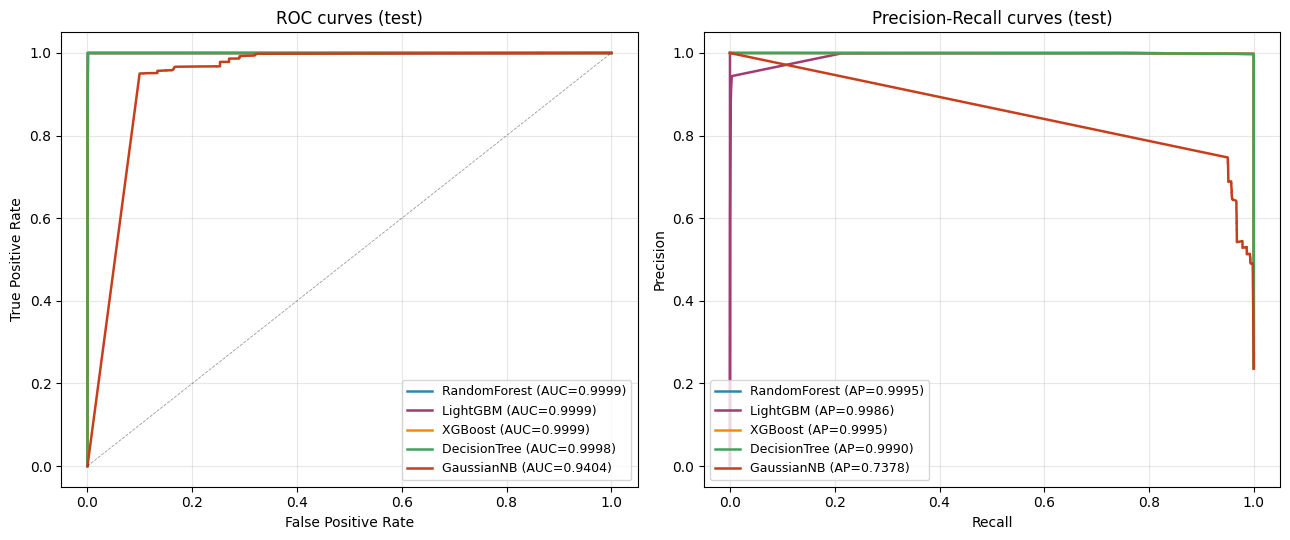

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

colors = {
    "RandomForest": "#2E86AB",
    "LightGBM":     "#A23B72",
    "XGBoost":      "#F18F01",
    "DecisionTree": "#3DA35D",
    "GaussianNB":   "#C73E1D",
}

# ROC
for name, res in results.items():
    if res["y_score_test"] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, res["y_score_test"])
    auc = res["metrics_test"]["roc_auc"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})",
                 color=colors[name], lw=1.8)
axes[0].plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves (test)")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

# PR
for name, res in results.items():
    if res["y_score_test"] is None:
        continue
    prec, rec, _ = precision_recall_curve(y_test, res["y_score_test"])
    ap = res["metrics_test"]["pr_auc"]
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.4f})",
                 color=colors[name], lw=1.8)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (test)")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_roc_pr_all.png", dpi=150, bbox_inches="tight")
plt.show()

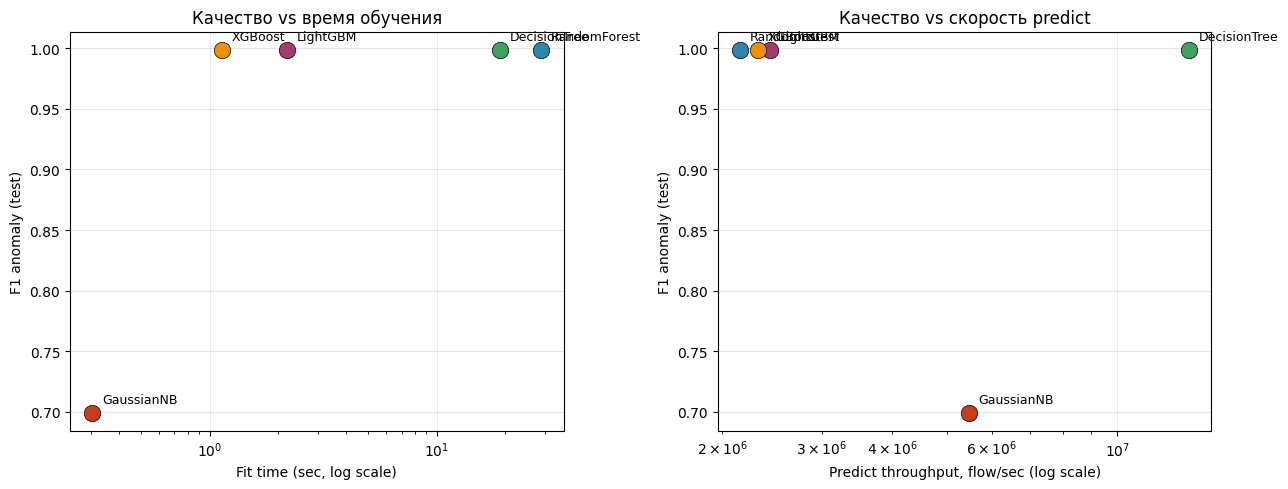

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) F1 vs fit_time
for name, res in results.items():
    f1 = res["metrics_test"]["f1_anomaly"]
    t  = res["fit_time"]
    axes[0].scatter(t, f1, s=140, color=colors[name], label=name,
                    edgecolor="black", linewidth=0.5, zorder=3)
    axes[0].annotate(name, (t, f1), textcoords="offset points",
                     xytext=(7, 7), fontsize=9)
axes[0].set_xscale("log")
axes[0].set_xlabel("Fit time (sec, log scale)")
axes[0].set_ylabel("F1 anomaly (test)")
axes[0].set_title("Качество vs время обучения")
axes[0].grid(alpha=0.3)

# (b) F1 vs throughput
for name, res in results.items():
    f1 = res["metrics_test"]["f1_anomaly"]
    thr = len(y_test) / res["predict_time_test"]
    axes[1].scatter(thr, f1, s=140, color=colors[name], label=name,
                    edgecolor="black", linewidth=0.5, zorder=3)
    axes[1].annotate(name, (thr, f1), textcoords="offset points",
                     xytext=(7, 7), fontsize=9)
axes[1].set_xscale("log")
axes[1].set_xlabel("Predict throughput, flow/sec (log scale)")
axes[1].set_ylabel("F1 anomaly (test)")
axes[1].set_title("Качество vs скорость predict")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_f1_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Bar-chart: F1_anomaly

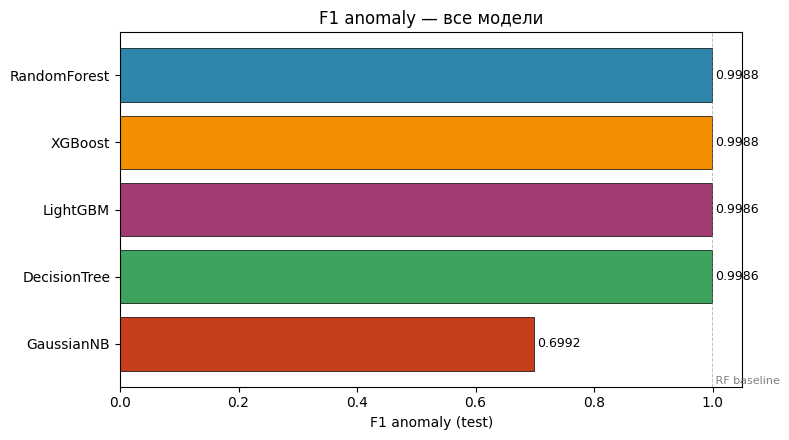

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = comparison.sort_values("f1_anomaly", ascending=True)
ax.barh(order["model"], order["f1_anomaly"],
        color=[colors[m] for m in order["model"]], edgecolor="black", lw=0.5)
for i, (_, row) in enumerate(order.iterrows()):
    ax.text(row["f1_anomaly"] + 0.005, i,
            f"{row['f1_anomaly']:.4f}", va="center", fontsize=9)
ax.set_xlabel("F1 anomaly (test)")
ax.set_title("F1 anomaly — все модели")
ax.set_xlim(0, 1.05)
ax.axvline(0.9988, color="grey", lw=0.7, ls="--", alpha=0.5)
ax.text(0.9988, -0.6, " RF baseline", color="grey", fontsize=8, ha="left")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_f1_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Сохранение артефактов 4 новых моделей

In [13]:
def save_classic_artifact(name: str, results: dict, params: dict,
                          extra: dict | None = None) -> Path:
    res = results[name]
    file_name = f"model_{name.lower()}.joblib"
    artifact = {
        "model_class_name":  type(res["model"]).__name__,
        "model_name_human":  name,
        "model_file":        file_name,
        "model":             res["model"],
        "model_features":    MODEL_FEATURES,
        "n_features":        42,
        "preprocessor_path": "preprocessor.joblib",
        "metrics_test":      res["metrics_test"],
        "metrics_train":     res["metrics_train"],
        "confusion_matrix_test":  res["cm_test"],
        "confusion_matrix_train": res["cm_train"],
        "training_config":   params,
        "fit_time_sec":      float(res["fit_time"]),
        "predict_time_test_sec": float(res["predict_time_test"]),
        "score_type":        "predict_proba",
        "decision_threshold": 0.5,
        "random_state":      RANDOM_STATE,
        "sklearn_version":   sklearn.__version__,
        "python_version":    sys.version.split()[0],
        "timestamp":         datetime.now().isoformat(timespec="seconds"),
    }
    if extra:
        artifact.update(extra)
    out = ARTIFACTS / file_name
    joblib.dump(artifact, out, compress=3)
    size_mb = out.stat().st_size / 1024**2
    print(f"  {file_name}  ({size_mb:.2f} MB)")
    return out

# LightGBM
save_classic_artifact("LightGBM", results, lgb_params,
                      extra={"library": "lightgbm",
                             "library_version": lgb.__version__})

# XGBoost — переключаем на CPU перед сохранением
results["XGBoost"]["model"].set_params(device="cpu")
save_classic_artifact("XGBoost", results, xgb_params,
                      extra={"library": "xgboost",
                             "library_version": xgb.__version__,
                             "trained_on_device": xgb_actual_device,
                             "saved_device": "cpu"})

# DecisionTree
save_classic_artifact("DecisionTree", results, dt_params)

# GaussianNB
save_classic_artifact("GaussianNB", results, {})

print("\nВсе артефакты сохранены.")

  model_lightgbm.joblib  (0.14 MB)
  model_xgboost.joblib  (0.08 MB)
  model_decisiontree.joblib  (0.02 MB)
  model_gaussiannb.joblib  (0.00 MB)

Все артефакты сохранены.


In [ ]:
# Загружаем каждый артефакт обратно и сверяем предсказания
for fname in ["model_lightgbm.joblib", "model_xgboost.joblib",
              "model_decisiontree.joblib", "model_gaussiannb.joblib"]:
    art = joblib.load(ARTIFACTS / fname)
    m = art["model"]
    sample = X_test_np[:1000]
    proba = m.predict_proba(sample)[:, 1]
    pred  = (proba >= art["decision_threshold"]).astype(int)
    # Сверка с оригинальными предсказаниями
    name_map = {
        "model_lightgbm.joblib": "LightGBM",
        "model_xgboost.joblib": "XGBoost",
        "model_decisiontree.joblib": "DecisionTree",
        "model_gaussiannb.joblib": "GaussianNB",
    }
    orig_name = name_map[fname]
    orig_proba = results[orig_name]["y_score_test"][:1000]
    max_diff = float(np.max(np.abs(proba - orig_proba)))
    print(f"  {fname}: max|Δproba|={max_diff:.2e} → "
          f"{'✓' if max_diff < 1e-5 else '✗'}")

  model_lightgbm.joblib: max|Δproba|=0.00e+00 → ✓
  model_xgboost.joblib: max|Δproba|=1.49e-08 → ✓
  model_decisiontree.joblib: max|Δproba|=0.00e+00 → ✓
  model_gaussiannb.joblib: max|Δproba|=0.00e+00 → ✓


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Итоги исследования

## 1) Рейтинг по F1_anomaly

| model         | F1_anomaly | overfit gap | fit_time | predict throughput | model size |
|---------------|-----------:|------------:|---------:|-------------------:|-----------:|
| RandomForest  | **0.9988** | +0.0001     | 29.2 сек | 2.33M flow/sec     | 1.9 MB     |
| **XGBoost**   | **0.9988** | +0.0001     | **1.24 сек** | 2.52M flow/sec | **80 KB** |
| LightGBM      | 0.9986     | +0.0002     | 2.10 сек | 2.52M flow/sec     | 148 KB     |
| DecisionTree  | 0.9986     | +0.0003     | 19.2 сек | **13.3M flow/sec** | 18 KB      |
| GaussianNB    | 0.6992     | -0.0001     | 0.30 сек | 5.55M flow/sec     | 2.1 KB     |

Разрыв между лучшей и худшей моделью — **30 п.п. по F1_anomaly**. Однако
внутри tree-based разрыв минимальный — все четыре модели в 3-м
знаке. Это означает, что задача в её бинарной формулировке решена с
запасом: дальнейшее улучшение возможно только сменой постановки
(multi-class, focus на редкие классы).


## 2) XGBoost - лучшая Classic ML модель

XGBoost (GPU) выигрывает у RF одновременно по трем осям:
- **скорость обучения**: 1.24 сек vs 29.2 сек (**×24** быстрее),
- **размер артефакта**: 80 KB vs 1.9 MB (**×24** меньше),
- **F1_anomaly**: идентичен 0.9988.

## 3) DecisionTree - неожиданно сильный и быстрый 

DT дает F1=0.9986 (отставание от RF/XGBoost — 0.0002 п.п.),
при этом predict-throughput **13.3M flow/sec** — в 5-6 раз выше любой
другой модели в сравнении. Это полезный практический вывод: на этом
датасете для inference в реальном времени достаточно одного дерева.


## 4) GaussianNB — предсказанная деградация подтверждена

F1_anomaly = 0.6992, **разрыв с tree-based 30 п.п.** Подтверждает три
предсказания из итогов 02:
1. NB страдает от нелинейности (recall=0.97 высокий, но precision=0.55 низкий —
   модель путает классы при сильно негауссовых распределениях),
2. NB страдает от мультиколлинеарности (26 пар с |p|>0.95 нарушают
   предположение независимости),
3. PR-AUC=0.738 при ROC-AUC=0.940 — сигнатура классификатора, который
   умеет ранжировать, но плохо ставит порог.

Это и есть учебная роль NB в сравнении — показать, что наивный подход
к структуре данных даёт измеримое падение качества (30 п.п.) даже на
простой задаче.


## 5) Скорость/Качество в продакшене

На диаграммах видно, что **XGBoost** в координатах (F1 vs fit_time): нет модели,
которая была бы и качественнее, и быстрее. 

- Для inference приоритеты могут меняться: DecisionTree обходит XGBoost по predict-throughput в 5 раз, ценой почти неощутимой потери качества (0.0002 п.п.).
